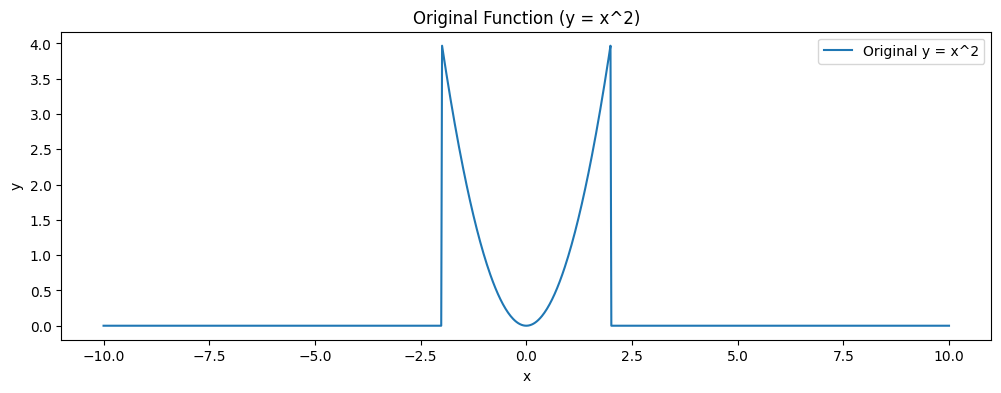

C:\Users\Asus\AppData\Local\Temp\ipykernel_22492\584271719.py:49: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ft_result_real[i] = np.trapz(signal * np.cos(2 * np.pi * freq * sampled_times), dx=dt)
C:\Users\Asus\AppData\Local\Temp\ipykernel_22492\584271719.py:50: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  ft_result_imag[i] = np.trapz(signal * np.sin(2 * np.pi * freq * sampled_times), dx=dt)


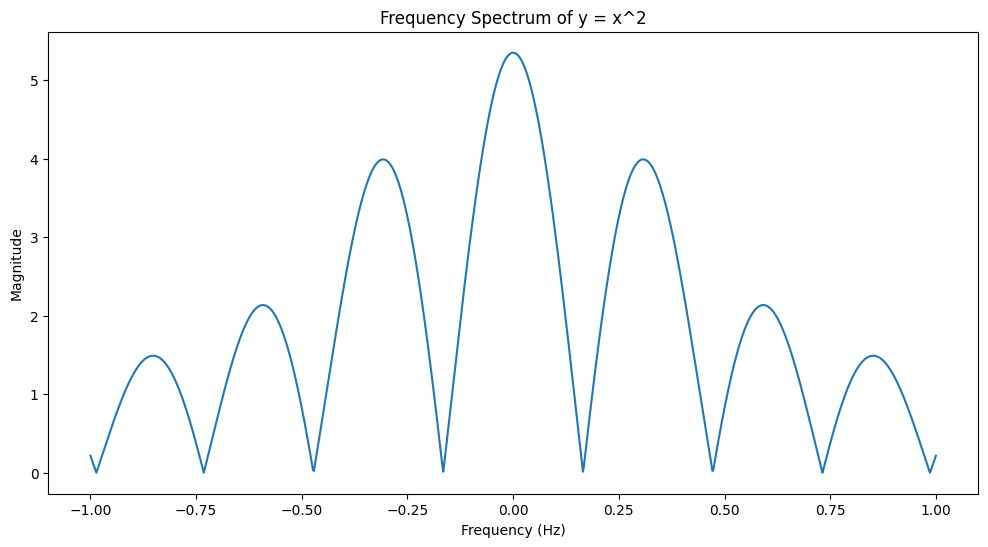

C:\Users\Asus\AppData\Local\Temp\ipykernel_22492\584271719.py:74: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  reconstructed_signal[i] = np.trapz(real_component , frequencies,frequencies[1]-frequencies[0])


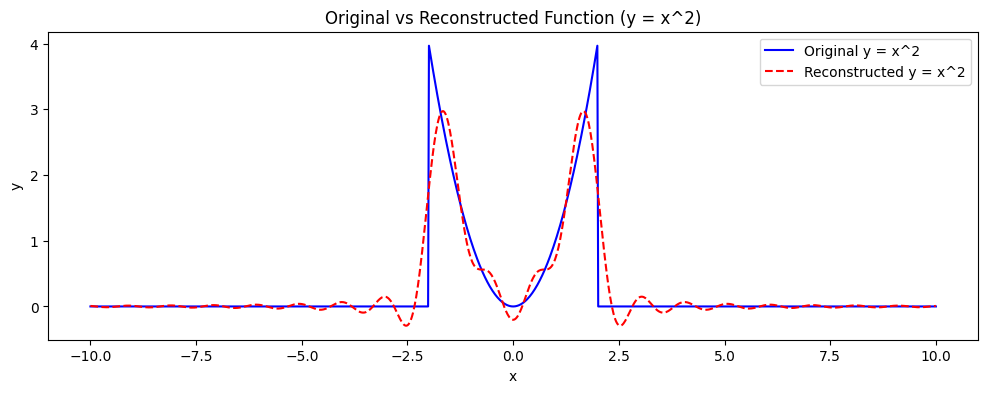

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Define the interval and function and generate appropriate x values and y values

def parabolic_function(x_values):
    return np.where((x_values >= -2) & (x_values <= 2), x_values**2, 0)

def triangular_function(x_values):
    return np.where((x_values >= -2) & (x_values <= 2), 1 - np.abs(x_values) / 2, 0)

def sawtooth_function(x_values):
    return np.where((x_values >= -2) & (x_values <= 2), (x_values + 2), 0)

def rectangular_function(x_values):
    return np.where((x_values >= -2) & (x_values <= 2), 1, 0)


x_values = np.linspace(-10, 10, 1000)
y_values = parabolic_function(x_values=x_values)

# Plot the original function
plt.figure(figsize=(12, 4))
plt.plot(x_values, y_values, label="Original y = x^2")
plt.title("Original Function (y = x^2)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()



# Define the sampled times and frequencies
sampled_times = x_values
frequencies =  np.linspace(-1, 1, 1000)

# Fourier Transform 
def fourier_transform(signal, frequencies, sampled_times):
    num_freqs = len(frequencies)
    ft_result_real = np.zeros(num_freqs)
    ft_result_imag = np.zeros(num_freqs)
    
    # Store the fourier transform results for each frequency. Handle the real and imaginary parts separately
    # use trapezoidal integration to calculate the real and imaginary parts of the FT

    dt = sampled_times[1] - sampled_times[0]
    
    for i, freq in enumerate(frequencies):
        ft_result_real[i] = np.trapz(signal * np.cos(2 * np.pi * freq * sampled_times), dx=dt)
        ft_result_imag[i] = np.trapz(signal * np.sin(2 * np.pi * freq * sampled_times), dx=dt)
    
    return ft_result_real, ft_result_imag   

# Apply FT to the sampled data
ft_data = fourier_transform(y_values, frequencies, sampled_times)
#  plot the FT data
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.sqrt(ft_data[0]**2 + ft_data[1]**2))
plt.title("Frequency Spectrum of y = x^2")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


def inverse_fourier_transform(ft_signal, frequencies, sampled_times):
    n = len(sampled_times)
    reconstructed_signal = np.zeros(n)
    ft_real, ft_imag = ft_signal

    for i, t in enumerate(sampled_times):

        real_component = ft_real * np.cos(2 * np.pi * frequencies * t)
        imag_component = ft_imag * np.sin(2 * np.pi * frequencies * t)
        reconstructed_signal[i] = np.trapz(real_component , frequencies,frequencies[1]-frequencies[0])

    return reconstructed_signal

  

# Reconstruct the signal from the FT data
reconstructed_y_values = inverse_fourier_transform(ft_data, frequencies, sampled_times)
# Plot the original and reconstructed functions for comparison
plt.figure(figsize=(12, 4))
plt.plot(x_values, y_values, label="Original y = x^2", color="blue")
plt.plot(sampled_times, reconstructed_y_values, label="Reconstructed y = x^2", color="red", linestyle="--")
plt.title("Original vs Reconstructed Function (y = x^2)")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()